#Conterfactual interpretability

## Importacion del dataset

### Importacion de librerias

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### Importacion del dataset via Kaggle API

In [4]:
from kaggle.api.kaggle_api_extended import KaggleApi

# Configuración
dataset_name = 'taweilo/loan-approval-classification-data'
file_name = 'loan_data.csv'  # El archivo específico dentro del dataset

os.environ['KAGGLE_USERNAME'] = 'potseleven'
os.environ['KAGGLE_KEY'] = '2b6b54ef59bcdf6cf76dbc0ab55d108c'

# 1. Autenticación e inicialización
api = KaggleApi()
api.authenticate()

# 2. Descargar si no existe
if not os.path.exists(file_name):
    print("Descargando dataset...")
    api.dataset_download_files(dataset_name, path='.', unzip=True)
else:
    print("El archivo ya existe, saltando descarga.")

# 3. Importar a tu flujo de trabajo (Ejemplo con Pandas)
try:
    df0= pd.read_csv(file_name)
    print("Dataset cargado exitosamente.")
    print(df0.head())
except Exception as e:
    print(f"Error al leer el archivo: {e}")

El archivo ya existe, saltando descarga.
Dataset cargado exitosamente.
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_scor

In [5]:
df= pd.read_csv('loan_data.csv')
df


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


##EDA


### Label Encoding and One-Hot Encoding

In [6]:
from sklearn.preprocessing import StandardScaler

# 2. Label Encoding (manual Label Encoding for more control)
# Convert gender: 'female' to 1 and 'male' to 0
df['person_gender'] = df['person_gender'].map({'female': 1, 'male': 0})

# Convert default history: 'Yes' to 1 and 'No' to 0
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})

# 3. One-Hot Encoding for multiple categorical variables
# These are the columns with more than two text options
columnas_nominales = ['person_education', 'person_home_ownership', 'loan_intent']

# The get_dummies function automatically creates new columns of 0s and 1s.
# We use drop_first=True to avoid the "dummy variable trap" (mathematical redundancy)
df = pd.get_dummies(df, columns=columnas_nominales, drop_first=True, dtype=int)

# 4. Separate features (X) from the target variable we want to predict (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 5. Scaling of numerical variables (StandardScaler)
# We select only the columns that have continuous values or large amounts
columnas_numericas = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

# Initialize the scaler and transform the data
scaler = StandardScaler()
X[columnas_numericas] = scaler.fit_transform(X[columnas_numericas])

# Verify how our final input matrix turned out
print(X.head())

   person_age  person_gender  person_income  person_emp_exp  loan_amnt  \
0   -0.953538              1      -0.104090       -0.892284   4.024953   
1   -1.118963              1      -0.846005       -0.892284  -1.359209   
2   -0.457264              1      -0.844065       -0.397517  -0.646600   
3   -0.788113              1      -0.007039       -0.892284   4.024953   
4   -0.622689              0      -0.176371       -0.727362   4.024953   

   loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
0       1.683039             4.016394                   -0.739109   
1       0.044782            -0.684829                   -0.996863   
2       0.625557             3.443074                   -0.739109   
3       1.417829             3.443074                   -0.996863   
4       1.095549             4.475050                   -0.481354   

   credit_score  previous_loan_defaults_on_file  ...  \
0     -1.419814                               0  ...   
1     -2.549975             

### Analisis de correlacion

Aqui se podria argumentar que algunas variables:
- `person_emp_exp`
- `cb_person_cred_hist_length`
- ` person_age `

Le llevarian informacion similar al modelo.

<Axes: >

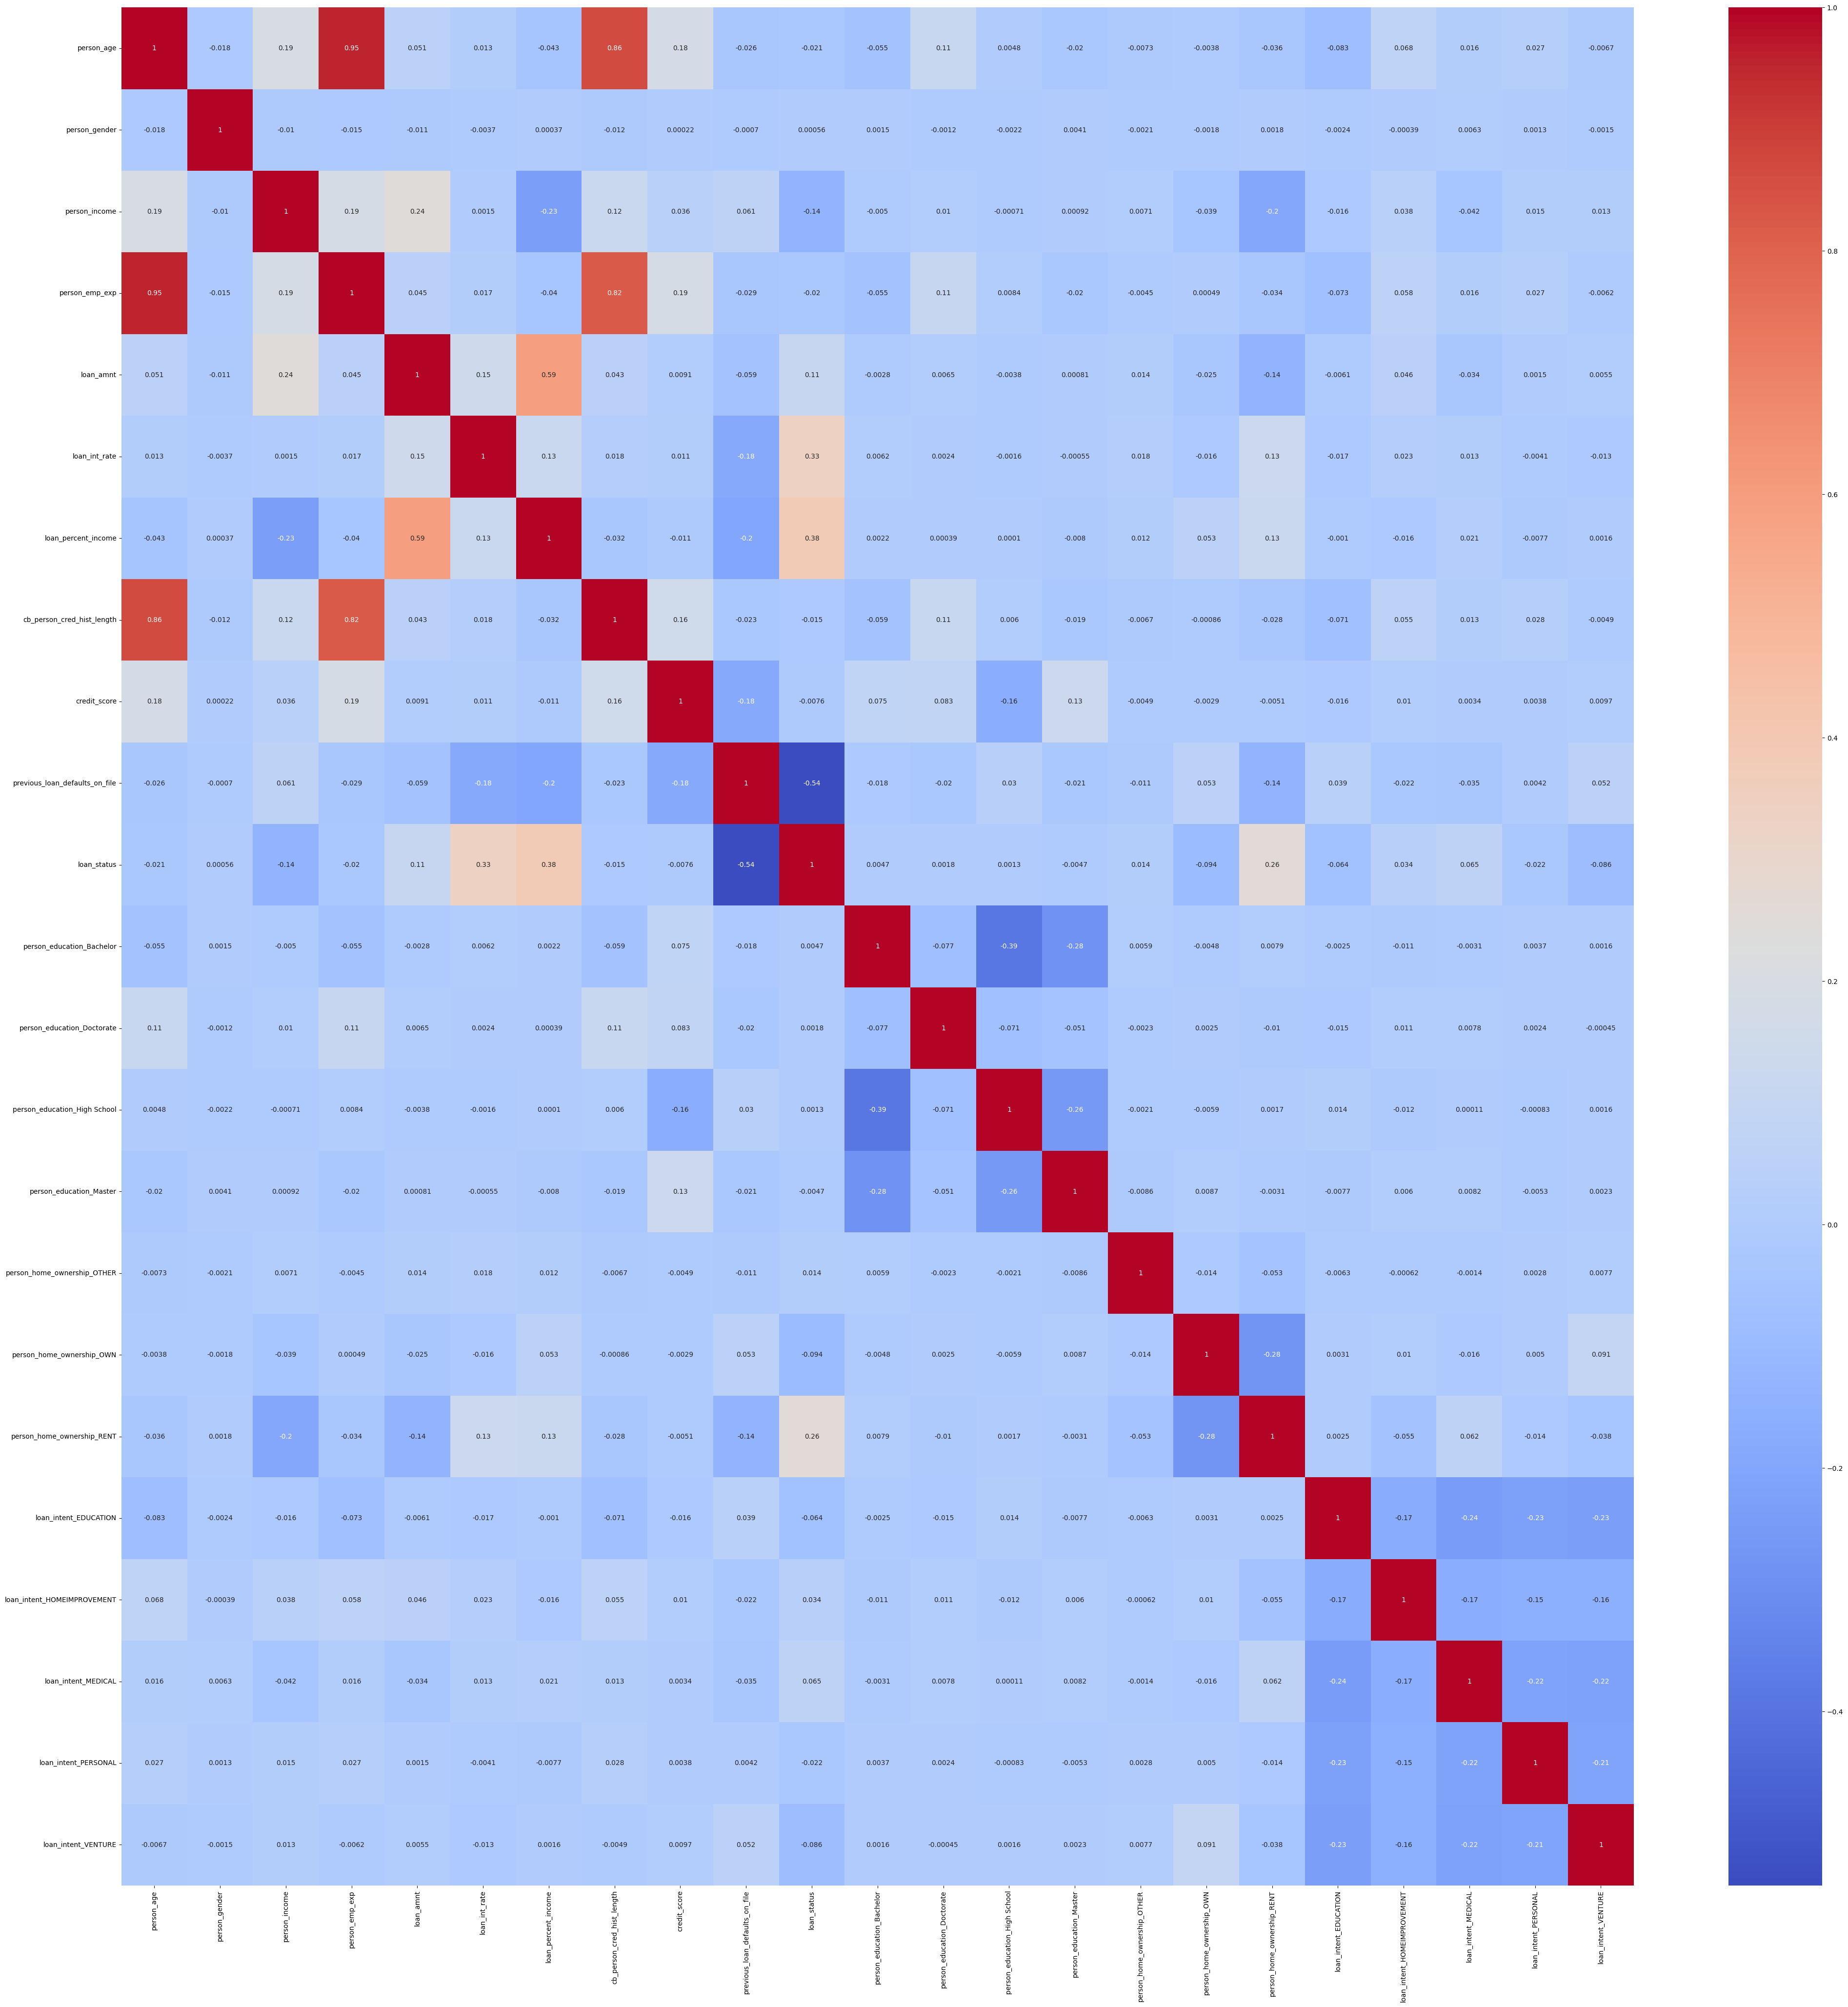

In [7]:
plt.figure(figsize=(50,50))
c = df.corr()
sns.heatmap(c,cmap="coolwarm",annot=True)

## Entrenamiento del modelo

### Division del dataset


In [8]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Construccion y entrenamiento del modelo

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



# 6. Construir y entrenar el modelo
input_dim = X_train.shape[1]
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(input_dim,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Usamos validation_data pasándole explícitamente nuestro set de prueba inmaculado
print("Iniciando el entrenamiento del modelo...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

model.save('modelo_credito.h5')
print("Modelo entrenado y guardado exitosamente como 'modelo_credito.h5'")

Iniciando el entrenamiento del modelo...
Epoch 1/20


c:\Users\POTES\.conda\envs\lore_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8835 - loss: 0.2605 - val_accuracy: 0.9024 - val_loss: 0.2144
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9082 - loss: 0.2012 - val_accuracy: 0.9103 - val_loss: 0.2032
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9122 - loss: 0.1947 - val_accuracy: 0.9094 - val_loss: 0.1999
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9139 - loss: 0.1904 - val_accuracy: 0.9116 - val_loss: 0.1957
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9163 - loss: 0.1868 - val_accuracy: 0.9137 - val_loss: 0.1924
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9163 - loss: 0.1839 - val_accuracy: 0.9146 - val_loss: 0.1906
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9183 - loss: 0.1816 - val_accuracy: 0.9164 - val_loss: 0.1890
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9184 - loss: 0.1800 - val_accurac

Modelo entrenado y guardado exitosamente como 'modelo_credito.h5'


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 1. Obtener la pérdida y precisión generales directamente desde Keras
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Precisión general del modelo: {accuracy * 100:.2f}%\n")

# 2. Generar las predicciones (probabilidades entre 0 y 1)
y_pred_prob = model.predict(X_test)

# 3. Convertir las probabilidades a clases binarias (0 o 1) usando 0.5 como umbral
y_pred = (y_pred_prob > 0.5).astype(int)

# 4. Mostrar métricas detalladas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred))

# 5. Ver un ejemplo visual de las primeras 10 predicciones frente a los valores reales
print("\n--- Primeras 10 predicciones vs reales ---")
# Convertimos y_test a un array para facilitar la visualización
y_test_array = y_test.values

for i in range(10):
    probabilidad = y_pred_prob[i]
    prediccion = y_pred[i]
    real = y_test_array[i]
    coincide = "✅" if prediccion == real else "❌"

    print(f"Probabilidad: {probabilidad[0]:.4f} | Predicción: {prediccion[0]} | Real: {real} {coincide}")

Precisión general del modelo: 91.96%

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step
--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6990
           1       0.85      0.78      0.81      2010

    accuracy                           0.92      9000
   macro avg       0.89      0.87      0.88      9000
weighted avg       0.92      0.92      0.92      9000

--- Matriz de Confusión ---
[[6714  276]
 [ 448 1562]]

--- Primeras 10 predicciones vs reales ---
Probabilidad: 0.0656 | Predicción: 0 | Real: 0 ✅
Probabilidad: 0.0000 | Predicción: 0 | Real: 0 ✅
Probabilidad: 0.7376 | Predicción: 1 | Real: 1 ✅
Probabilidad: 0.0000 | Predicción: 0 | Real: 0 ✅
Probabilidad: 0.5376 | Predicción: 1 | Real: 1 ✅
Probabilidad: 0.1003 | Predicción: 0 | Real: 0 ✅
Probabilidad: 0.0000 | Predicción: 0 | Real: 0 ✅
Probabilidad: 0.9704 | Predicción: 1 | Real: 1 ✅
Probabilidad: 0.2929 | Predicción: 0 | Real: 1 ❌
Probabilidad: 0.454

In [11]:
from blackbox_wrapper import BlackBoxWrapper


# 1. Cargas tu modelo entrenado de TensorFlow
my_tf_model = model

# 2. Inicializas nuestro Wrapper
wrapper = BlackBoxWrapper(my_tf_model, threshold=0.5)

# Convertimos el DataFrame de características de prueba a una matriz de NumPy
mi_matriz_numpy = X_test.values  # Su forma (shape) será (N, m)
# 3. Haces una predicción de prueba para verificar que devuelva un array plano de 0 y 1
clases_sinteticas = wrapper.predict(mi_matriz_numpy)
print(clases_sinteticas)  # Debería imprimir algo como: [1 0 1 1 0]

[0 0 1 ... 0 0 1]


In [12]:
from data_utils import DatasetMetadata, calculate_distance

# ==========================================
# PASO 1: Carga tus datos reales
# ==========================================
# Carga el dataset que usaste para entrenar o validar (background dataset)
# Este dataset DEBE contener únicamente las columnas de entrada (features) que recibe tu modelo, sin la columna objetivo (label/target)


df_referencia = df  # Reemplaza con tu archivo real

# Si tu dataset tiene la columna objetivo (label/target), elimínala primero:
if 'loan_status' in df_referencia.columns:
    df_referencia = df_referencia.drop(columns=['loan_status'])

# ==========================================
# PASO 2: Identifica tus columnas categóricas
# ==========================================
# Haz una lista con los nombres exactos de las columnas que sean categóricas (strings, categorías)
# El resto de las columnas se asumirán automáticamente como continuas/numéricas
columnas_categoricas_reales = []  # <--- Reemplaza con las tuyas

# Inicializa los metadatos con tu estructura real
metadata_real = DatasetMetadata(df_referencia, categorical_cols=columnas_categoricas_reales)

# ==========================================
# PASO 3: Extrae la instancia 'x' a explicar
# ==========================================
# Seleccionamos la primera fila como un DataFrame de Pandas
df_test = df.iloc[0:1].copy()

# Si tu conjunto de testeo aún tiene la columna objetivo, la eliminamos
# (Asegúrate de cambiar 'target_col' por el nombre real de tu etiqueta si existe)
columnas_a_borrar = ['loan_status']
for col in columnas_a_borrar:
    if col in df_test.columns:
        df_test = df_test.drop(columns=[col])

# Extraemos la fila como un array UNIDIMENSIONAL de NumPy (shape: (m,))
# Usar .iloc[0].to_numpy() obtiene la primera fila como un vector NumPy 1D
x_real = df_test.iloc[0].to_numpy()

# Construimos la matriz de referencia Z (N, m) que requiere calculate_distance
Z = df_referencia.to_numpy()

# Verificamos las dimensiones:
# x_real.shape debe ser (m,)
# Z.shape debe ser (N, m)
print(f"Instancia x tiene {len(x_real)} características. Tipo de objeto: {type(x_real)}")
print(f"El dataset de referencia tiene {Z.shape[1]} características. Dimensiones: {Z.shape}")

# Opcional: Verificación de alineación de características
if len(x_real) != Z.shape[1]:
    print("⚠️ ¡Alerta! El número de características de 'x' no coincide con el dataset de referencia.")
else:
    print("✅ Dimensiones alineadas y listas para inicializar LORE.")

# Calculamos distancias de x a cada fila de Z
distancias = calculate_distance(x_real, Z, metadata_real)
print("Distancias calculadas (primeros 10):", distancias[:10])

# 5. Probamos el muestreo empírico para mutaciones
print("Muestreo empírico de 'loan_intent':", metadata_real.sample_empirical('cb_person_cred_hist_length', size=3))

Instancia x tiene 22 características. Tipo de objeto: <class 'numpy.ndarray'>
El dataset de referencia tiene 22 características. Dimensiones: (45000, 22)
✅ Dimensiones alineadas y listas para inicializar LORE.
Distancias calculadas (primeros 10): [0.         2.19612243 1.6079153  1.20005471 0.92225359 2.08208979
 1.30279638 1.2096033  0.86818604 2.08265649]
Muestreo empírico de 'loan_intent': [5. 2. 4.]


In [13]:
from genetic_generator import GeneticNeighborhoodGenerator
# Asumimos que 'wrapper', 'metadata' y 'x' ya están inicializados 
# según los pasos de las pruebas anteriores.

# Inicializamos el generador con los parámetros recomendados para producción
generator = GeneticNeighborhoodGenerator(population_size=500, generations=10)

# 1. Generar la vecindad Factual Z_(=)
Z_factual = generator.generate(x_real, wrapper, metadata_real, target_factual=True)
print("Forma de la matriz Z factual:", Z_factual.shape)

# 2. Generar la vecindad Contrafactual Z_(≠)
Z_counterfactual = generator.generate(x_real, wrapper, metadata_real, target_factual=False)
print("Forma de la matriz Z contrafactual:", Z_counterfactual.shape)

Forma de la matriz Z factual: (500, 22)
Forma de la matriz Z contrafactual: (500, 22)


In [15]:
from surrogate_tree import SurrogateTreeEvaluator
import numpy as np

# 1. Unimos el vecindario local Z = Z_(=) U Z_(≠)
Z = np.vstack((Z_factual, Z_counterfactual))

# 2. Obtenemos las etiquetas oráculo llamando de nuevo a tu modelo TensorFlow (Wrapper)
y_Z = wrapper.predict(Z)

# 3. Inicializamos el evaluador del árbol
tree_evaluator = SurrogateTreeEvaluator(metadata_real)

# 4. Ajustamos el árbol de decisión local
tree_evaluator.fit_local_tree(Z, y_Z)

# 5. Extraemos la regla factual
factual_rule = tree_evaluator.extract_factual_rule(x_real)
factual_pred = factual_rule['prediction']
print(f"Predicción Factual: {factual_pred}")
print("Regla Factual:")
for cond in factual_rule['conditions']:
    print(f"  - {cond['feature']} {cond['op']} {cond['threshold']:.4f}")

# 6. Extraemos las reglas contrafactuales
counterfactuals = tree_evaluator.extract_counterfactual_rules(x_real, factual_pred)
print(f"\nSe encontraron {len(counterfactuals)} conjunto(s) de reglas contrafactuales óptimas:")
for i, cf in enumerate(counterfactuals):
    print(f"Opción {i+1} (Predicción -> {cf['prediction']}, Costo nf -> {cf['nf']}):")
    for cond in cf['conditions']:
        print(f"  - {cond['feature']} {cond['op']} {cond['threshold']:.4f}")

Predicción Factual: 0
Regla Factual:
  - person_income <= 72277.0000
  - cb_person_cred_hist_length <= 5.5000

Se encontraron 1 conjunto(s) de reglas contrafactuales óptimas:
Opción 1 (Predicción -> 1, Costo nf -> 1):
  - person_income > 72277.0000
  - person_income <= 85431.0000
  - person_income <= 72817.5000
